# Tennis Over/Under **Total Games** — Viability Analysis

**Question:** should SportPIQ add an Over/Under *total games* market for tennis, and can the
model we already have predict it?

**Answer, in one line:** the market is worth building, but **not on the features we have
today** — they carry essentially no signal about game count. Two other signals do.

---

### Why this analysis exists at all

The football Over/Under goals market shipped on top of a model that could not predict goals.
Measured afterwards, predicted xG correlated with actual total goals at **r = +0.030**, and
every reliability bucket sat flat at the base rate — a confident-looking percentage with
nothing behind it. It took an xG data collection, out-of-fold stacking and feature pruning to
turn that around.

This notebook is the measurement that was skipped that time, run *before* anything is built.

### Reproducing this

Self-contained. Needs only `tennis_game_counts_atp.parquet` (ships alongside this notebook) —
no API key, no database, no network.

```
pip install pandas numpy matplotlib pyarrow
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.width", 110)
DATA = Path("tennis_game_counts_atp.parquet")   # same folder as this notebook

df = pd.read_parquet(DATA)
print(f"{len(df):,} completed ATP matches, seasons {df.SEASON.min()}-{df.SEASON.max()}")
df.head()

17,273 completed ATP matches, seasons 2021-2025


,MATCH_ID,SEASON,GAME_DATE,HOME_ID,AWAY_ID,SURFACE,total_games,first_set_games,n_sets,HOME_RANK_POINTS,AWAY_RANK_POINTS
0,859,2021,2021-05-02,3,55,Clay,32,13,3,6142.5,1601.0
1,860,2021,2021-05-02,3,222118,Clay,19,9,2,6142.5,567.5
2,861,2021,2021-05-02,12,55,Clay,20,10,2,3890.0,1601.0
3,862,2021,2021-05-02,3,222119,Clay,20,10,2,6142.5,6020.0
4,863,2021,2021-05-02,222118,222169,Clay,28,9,3,567.5,1616.0


## What is in the data

One row per **completed** ATP match, derived from the provider's `set_scores`.

| column | meaning |
|---|---|
| `total_games` | games played across the whole match |
| `first_set_games` | games in set 1 |
| `n_sets` | sets played |
| `SURFACE` | Hard / Clay / Grass |
| `HOME_RANK_POINTS`, `AWAY_RANK_POINTS` | median ranking points |

**Retirements and walkovers are excluded.** A match abandoned mid-set has a total that is not
comparable to a completed one, and that total is exactly what the market prices. Including
them would drag the mean down with matches that were never contested to a conclusion.

`HOME`/`AWAY` in tennis is **not** a real distinction — there is no home court. It is a stable
id-based tiebreak used only so a fixture's identity cannot flip between ingests.

In [2]:
print(f"excluded (retirement / incomplete set / walkover): "
      f"not present in this file by construction")
print(f"\nmatches per season:")
print(df.SEASON.value_counts().sort_index().to_string())
print(f"\nsurface mix:")
print(df.SURFACE.value_counts(dropna=False).to_string())

excluded (retirement / incomplete set / walkover): not present in this file by construction

matches per season:
SEASON
2021    2940
2022    3168
2023    3505
2024    3672
2025    3988

surface mix:
SURFACE
Hard          9228
Clay          5655
Grass         2105
Grass          190
None            95


## 1. Is there variance worth predicting?

A market only makes sense if the outcome genuinely varies. If nearly every match landed on 22
games there would be nothing to forecast.

,mean,std,min,25%,50%,75%,max
total_games,25.40,8.14,12.0,19.0,23.0,30.0,64.0
first_set_games,9.97,1.97,6.0,9.0,10.0,12.0,13.0


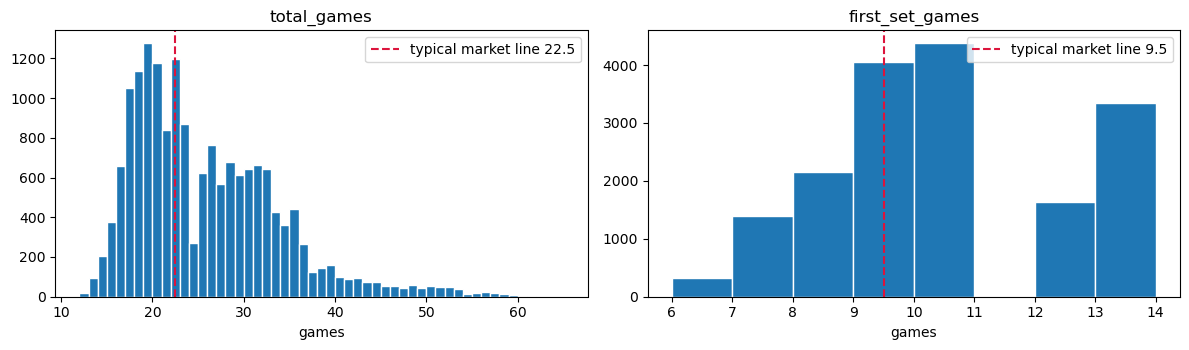

In [3]:
summary = df[["total_games", "first_set_games"]].describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
]
display(summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, col, line in zip(axes, ["total_games", "first_set_games"], [22.5, 9.5]):
    ax.hist(df[col], bins=range(int(df[col].min()), int(df[col].max()) + 2), edgecolor="white")
    ax.axvline(line, color="crimson", ls="--", label=f"typical market line {line}")
    ax.set_title(col); ax.set_xlabel("games"); ax.legend()
plt.tight_layout(); plt.show()

### Base rates against the market's own lines

These are the lines bookmakers actually offer (confirmed live in TheRundown's ATP feed:
21.5 / 22 / 22.5 / 23.5 for match totals).

In [4]:
rows = []
for line in (21.5, 22.5, 23.5):
    rows.append({"market": "total games", "line": line,
                 "P(over)": (df.total_games > line).mean()})
for line in (9.5, 10.5):
    rows.append({"market": "first-set games", "line": line,
                 "P(over)": (df.first_set_games > line).mean()})
base = pd.DataFrame(rows)
base["P(over)"] = base["P(over)"].round(3)
display(base)

print("The lines sit close to a coin flip, which means they are well set.")
print("Beating them needs real signal, not a sensible prior.")

,market,line,P(over)
0,total games,21.5,0.605
1,total games,22.5,0.535
2,total games,23.5,0.485
3,first-set games,9.5,0.542
4,first-set games,10.5,0.288


The lines sit close to a coin flip, which means they are well set.
Beating them needs real signal, not a sensible prior.


**Read:** total games has real spread — sd **8.1** on a mean of **25.4**, ranging 12 to 64.
First-set games is far tighter: sd **2.0** on a mean of **10.0**, and bounded 6–13 by the rules
of a set. Less room to be right, and less room to be wrong.

## 2. Do the features the model already has predict it?

The live tennis model is a **binary win/loss classifier**. Its strongest input is the ranking
gap. If a rankings mismatch does not change how long a match runs, then a feature set built to
answer *who wins* is unlikely to answer *how long* either.

`rank_diff` is signed (home minus away). `rank_gap` is its absolute value — the mismatch size,
regardless of who is favoured, which is the more plausible driver of a short match.

In [5]:
d = df.dropna(subset=["HOME_RANK_POINTS", "AWAY_RANK_POINTS"]).copy()
d["rank_diff"] = d.HOME_RANK_POINTS - d.AWAY_RANK_POINTS
d["rank_gap"] = d.rank_diff.abs()

def corr_ci(x, y):
    """Pearson r with a 95% CI via Fisher's z — the CI matters more than r at this n."""
    ok = x.notna() & y.notna()
    x, y = x[ok], y[ok]
    r = np.corrcoef(x, y)[0, 1]
    se = 1 / np.sqrt(len(x) - 3)
    lo, hi = np.tanh(np.arctanh(r) - 1.96 * se), np.tanh(np.arctanh(r) + 1.96 * se)
    return r, lo, hi, len(x)

rows = []
for feat in ("rank_diff", "rank_gap"):
    for target in ("total_games", "first_set_games"):
        r, lo, hi, n = corr_ci(d[feat], d[target])
        rows.append({"feature": feat, "target": target, "r": round(r, 3),
                     "CI low": round(lo, 3), "CI high": round(hi, 3),
                     "r^2 (% variance)": round(100 * r * r, 2), "n": n})
display(pd.DataFrame(rows))

,feature,target,r,CI low,CI high,r^2 (% variance),n
0,rank_diff,total_games,0.023,0.008,0.038,0.05,17051
1,rank_diff,first_set_games,-0.014,-0.029,0.001,0.02,17051
2,rank_gap,total_games,0.051,0.036,0.066,0.26,17051
3,rank_gap,first_set_games,-0.016,-0.031,-0.001,0.03,17051


### Interpretation — the important cell

`rank_gap` vs `total_games` reaches **r ≈ +0.05** with a confidence interval that excludes
zero. At n = 17,000 almost anything excludes zero, so that is *statistically* detectable and
*practically* nothing: it explains about **0.25% of the variance**.

For scale, the football Over/Under failure measured **r = +0.030** on the same kind of check.
These features are in the same territory. Building the market on them would reproduce that
result exactly.

**First-set games shows nothing at all** — both features sit at |r| < 0.02.

## 3. What *does* carry signal

Two things, and neither is in the model today.

In [6]:
surf = (df.assign(SURFACE=df.SURFACE.str.strip())      # provider emits "Grass" AND "Grass     "
          .dropna(subset=["SURFACE"])
          .groupby("SURFACE")["total_games"]
          .agg(["mean", "std", "count"]).round(2))
display(surf)
print(f"spread across surfaces : {surf['mean'].max() - surf['mean'].min():.2f} games")
print(f"overall sd             : {df.total_games.std():.2f} games")

,mean,std,count
SURFACE,,,
Clay,24.49,7.44,5655
Grass,28.12,9.63,2295
Hard,25.31,8.03,9228


spread across surfaces : 3.63 games
overall sd             : 8.14 games


**Surface.** Grass runs ~4.5 games longer than clay on average. We already have this field for
every match — it costs nothing to use.

> Note the `.str.strip()` above. The provider returns both `"Grass"` and `"Grass     "` as real
> values, and 190 of 2,295 grass matches carry the padded form. Compared exactly, one surface
> becomes two. This was a live bug in the production feature code, found by this analysis and
> since fixed.

players with >= 30 matches : 279


their average total games  : 21.8 to 30.6  (population mean 25.4)
sd between player averages : 1.49 games


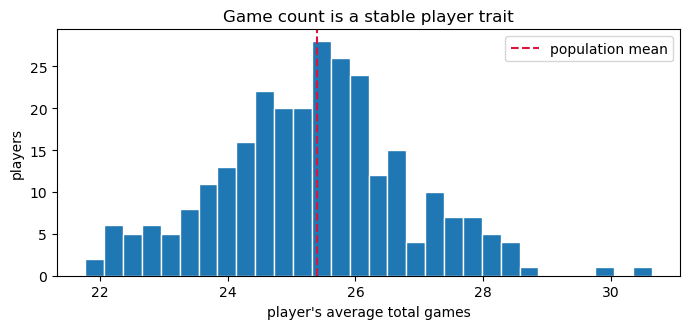

In [7]:
long = pd.concat([
    df[["HOME_ID", "total_games"]].rename(columns={"HOME_ID": "player"}),
    df[["AWAY_ID", "total_games"]].rename(columns={"AWAY_ID": "player"}),
])
per_player = long.groupby("player").total_games.agg(["mean", "count"])
regulars = per_player[per_player["count"] >= 30]

print(f"players with >= 30 matches : {len(regulars)}")
print(f"their average total games  : {regulars['mean'].min():.1f} to {regulars['mean'].max():.1f}"
      f"  (population mean {df.total_games.mean():.1f})")
print(f"sd between player averages : {regulars['mean'].std():.2f} games")

plt.figure(figsize=(7, 3.4))
plt.hist(regulars["mean"], bins=30, edgecolor="white")
plt.axvline(df.total_games.mean(), color="crimson", ls="--", label="population mean")
plt.xlabel("player's average total games"); plt.ylabel("players"); plt.legend()
plt.title("Game count is a stable player trait"); plt.tight_layout(); plt.show()

**Player tendency.** Across 279 regulars, average total games spans **21.8 to 30.6**. Big
servers hold easily and produce short sets; grinders produce long ones. That is a real,
learnable trait — and precisely the kind of feature the current win-probability set lacks.

A caution before trusting it: some of that spread is *opponent quality*, not style. A player
who mostly faces weaker opposition wins quickly regardless of how they play. Separating the two
is part of the modelling work, not something this notebook settles.

## 4. Conclusion and recommendation

| | verdict |
|---|---|
| **Total games (pre-match)** | **Build it** — but on new features, not the existing ones |
| **First-set games** | **Skip** — least variance, no measurable signal, near coin-flip base rate |
| **Live / in-play** | **Separate project** — needs real-time ingest; a 5-minute-old in-play price is misleading, not merely stale |

### Features to build, in order of cost

1. **Player rolling average games** (last N matches, and split by surface) — derivable from the
   data in this notebook. **No new subscription.**
2. **Surface** — already collected for every match. Free.
3. **Opponent-adjusted tendency** — controls for the confound noted above. Free, just modelling.
4. **Serve statistics** — hold %, break points, aces, tiebreak frequency. The strongest
   candidates, and the only ones needing a **paid tier upgrade** (verified: `/match_stats`
   returns **401** on the current plan).

The honest sequence is to build 1–3 first, measure whether they beat the base rate, and only
buy the tier if they do. That is the opposite order to how the football market was built.